#### Instalacion de librerias

In [ ]:
!pip install random-forest-mc
!pip install jupyter
!pip install ydata-profiling

#### Importacion de librerias

In [ ]:
# importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport
import re
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from imblearn.over_sampling import SMOTE, SMOTENC
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (accuracy_score, mutual_info_score, mean_squared_error, r2_score,
    make_scorer, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix,
    classification_report, log_loss)
import statsmodels.api as sm
from google.colab import drive
from IPython.display import display
import hashlib
from scipy.stats import skew, chi2_contingency
import lightgbm as lgb
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

#### Carga de documento Colab con drive

In [ ]:
# Carga de datos manual (merged entre X_train e Y_train)
data_training = pd.read_csv('training_merged.csv')

In [ ]:
## Carga de datos manual de test_set_values_x_test
X_comp = pd.read_csv('test_set_values_x_test.csv')

In [ ]:
#drive.mount('/content/drive')

# Definimos rutas de los archivos originales en Drive
#path_labels = '/content/drive/MyDrive/COMPLUTENSE_MASTER/11_machine_learning3/modelo_driven_data/training_set_labels_y_train.csv'
#path_values = '/content/drive/MyDrive/COMPLUTENSE_MASTER/11_machine_learning3/modelo_driven_data/training_set_values_x_train.csv'

# Cargamos los archivos originales
#y_training_labels = pd.read_csv(path_labels)
#x_training_values = pd.read_csv(path_values)

# Hacemos el merge usando 'id'
#training_merged = x_training_values.merge(y_training_labels, on="id")

# Guardamos el nuevo dataset unido en Drive (con otro nombre para no pisar los originales)
#merged_path = '/content/drive/MyDrive/COMPLUTENSE_MASTER/11_machine_learning3/modelo_driven_data/training_merged.csv'
#training_merged.to_csv(merged_path, index=False)

#print("Dataset unido guardado en Drive en la carpeta modelo_driven_data:")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset unido guardado en Drive en la carpeta modelo_driven_data:


In [ ]:
#data_training = pd.read_csv('/content/drive/MyDrive/COMPLUTENSE_MASTER/11_machine_learning3/modelo_driven_data/training_merged.csv')
#X_comp = pd.read_csv("/content/drive/MyDrive/COMPLUTENSE_MASTER/11_machine_learning3/modelo_driven_data/test_set_values_x_test.csv")

#### Definicion del problema o investigacion

*Introducción*

El acceso al agua potable es un desafío crítico en Tanzania, donde miles de comunidades dependen de bombas de agua para abastecerse en su vida diaria. Sin embargo, una gran proporción de estas bombas presenta fallos o se encuentra en riesgo de dejar de funcionar, lo que limita gravemente el acceso al recurso más básico para la salud y el desarrollo.

El problema que se plantea es predecir el estado de funcionamiento de las bombas de agua a partir de la información disponible en el dataset (características técnicas, ubicación, gestión, construcción, entre otras). La variable objetivo clasifica cada bomba en tres categorías:

- Functional (operativa),
- Non functional (fuera de servicio),
- Functional needs repair (en funcionamiento pero requiere reparaciones).

El objetivo de este análisis es desarrollar un modelo de machine learning que permita anticipar el estado de una bomba a partir de sus características, de manera que las autoridades y organizaciones puedan priorizar recursos, planificar mantenimientos preventivos y mejorar la sostenibilidad del acceso al agua en Tanzania

#### Exploración inicial (EDA preliminar) + Profile

Evaluamos cuantos nulos tiene cada variable

In [ ]:
# Calcular el porcentaje de nulos por columna
null_percentage = (data_training.isnull().sum() / len(data_training) * 100)

# Filtrar solo las columnas que tienen al menos un valor nulo
null_percentage = null_percentage[null_percentage > 0]
null_percentage = null_percentage.sort_values(ascending=False)
print(null_percentage)

scheme_name          48.501684
scheme_management     6.528620
installer             6.153199
funder                6.122896
public_meeting        5.612795
permit                5.144781
subvillage            0.624579
wpt_name              0.003367
dtype: float64


In [ ]:
# Calcular ahora solo el numero de nulos por columna
null_num = (data_training.isnull().sum())

# Filtrar solo las columnas que tienen al menos un valor nulo
null_num = null_num[null_num > 0]
null_num = null_num.sort_values(ascending=False)
print(null_num)

scheme_name          28810
scheme_management     3878
installer             3655
funder                3637
public_meeting        3334
permit                3056
subvillage             371
wpt_name                 2
dtype: int64


Evaluamos cuantos zeros tiene cada variable

In [ ]:
# Filtrar solo columnas numéricas
numeric_cols = data_training.select_dtypes(include=["int64", "float64"]).columns

# Calcular conteo de ceros y porcentaje
zero_counts = (data_training[numeric_cols] == 0).sum()
zero_perc = ((data_training[numeric_cols] == 0).sum() / len(data_training)) * 100

# Combinar resultados en un DataFrame
zeros_df = pd.DataFrame({"Zero_Count": zero_counts, "Zero_Percentage": zero_perc})

# Filtrar solo columnas que tienen al menos un cero y ordenarlas
zeros_df = zeros_df[zeros_df["Zero_Count"] > 0].sort_values(by="Zero_Percentage", ascending=False)

# Mostrar tabla
display(zeros_df)

,Zero_Count,Zero_Percentage
num_private,58643,98.725589
amount_tsh,41639,70.099327
population,21381,35.994949
construction_year,20709,34.863636
gps_height,20438,34.407407
longitude,1812,3.050505
district_code,23,0.038721
id,1,0.001684


Insight de variables con mayor cantidad de zeros:
- num_private: No hay informacion sobre esta variable yaa
- amount_tsh: Cantidad de agua disponible en el punto de agua
- population: Número de habitantes alrededor del pozo (población beneficiada)
- construction_year: Año en que se construyó el pozo.
- gps_height: Altitud del pozo respecto al nivel del mar (en metros).

Evaluamos y **amount_tsh** tiene cerca del 70% de los registros con valor 0, lo cual resulta poco coherente. Si un pozo no cuenta con agua, no debería considerarse funcional; por lo tanto, estos ceros pueden interpretarse como datos atípicos o registros erróneos.

Es posible que **population** tenga esa cantidad de 0 ya que en contextos como Tanzania, si un pozo deja de funcionar, la comunidad puede desplazarse a otra zona en busca de agua.

De **construction_year** No resulta lógico que existan valores en 0, ya que los pozos no pueden tener miles de años de antigüedad. En este caso, los ceros deben considerarse como datos faltantes o mal registrados.

Y de la variable **gps_height** sí es factible la existencia de valores en 0, ya que algunas comunidades se encuentran efectivamente a nivel del mar.

Libreria de Profile

In [ ]:
# Creacion del profile
profile_training = ProfileReport(data_training, title="Profiling Report")
profile_training.to_file("profiling_report_driven.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 41/41 [00:20<00:00,  2.02it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# Guardar en Colab
#profile_training.to_file("profiling_report_banco.html")

# Descargar en la PC
#files.download("profiling_report_driven.html")

In [ ]:
# Si prefieres verlo sin salir de Colab:
profile_training.to_notebook_iframe()

Output hidden; open in https://colab.research.google.com to view.

**Variables numéricas**

*amount_tsh*

- Tipo: numérica continua.
- 70% de valores en cero (posible indicador de “sin agua” o “dato faltante”).
- Solo 98 valores distintos → baja variabilidad.
- Media afectada por outliers (máximo = 350.000).
- Correlación positiva con construction_year (0,41).


*date_recorded*
- Tipo: temporal.
- Rango: 2002–2013 (mayoría entre 2011–2013).
- 356 fechas distintas, sin valores faltantes.

*gps_height*
- Tipo: numérica continua.
- 34,4% de valores en cero.
- Rango: -90 a 2770 metros (outliers negativos).
- Fuertes correlaciones con construction_year, region y population.


*longitude / latitude*
- Tipo: coordenadas geográficas (numéricas).
- Longitude: 3,1% ceros, correlación con region (0,79).
- Latitude: todos los valores negativos (rango -11,6 a ≈0), ligera asimetría.


*num_private*
- Tipo: numérica, poco informativa.
- 98,7% de valores en cero.
- Acción: recodificar como binaria (0 = no privado, 1 = privado). Posible eliminación. Lo veremos mas adelante

*population*
- Tipo: numérica continua.
- 36% de valores en cero.
- Rango: 0–30.500.
- Correlación con construction_year (0,68).

*construction_year*
- Tipo: numérica ordinal (año).
- 34,9% de valores en cero (missing codificado).
- Rango válido: 1900–2013.
- Correlación fuerte con region (0,94).


**Variables categóricas**

*basin*
- 9 categorías.
- Alta correlación con region.

*region*
- 21 categorías.
- Correlación fuerte con basin y region_code.

*region_code / district_code*

- Numéricas, pero representan categorías.
- Acción: tratarlas como categóricas nominales.

*lga*

- 125 categorías.
- Acción: codificación por frecuencia o agrupación de categorías poco comunes.

*ward*

- 2092 categorías (alta cardinalidad).
- Acción: aplicar agrupación o codificación por frecuencia.

*public_meeting / permit*

- Booleanas con pocos missing.

*recorded_by*

- Única categoría.
- Acción: eliminar (no aporta información).

**Variables categóricas de alta cardinalidad**

*funder*

- 1896 categorías, 3,4% missing.
- Acción: Aplicar frecuencia encoding.

*installer*

- 2145 categorías, 6,2% missing.
- Acción: mismo tratamiento que funder, posible agrupación conjunta.

*wpt_name*

- 37.399 categorías, 63% distintas.
- Acción: eliminar (demasiado dispersa, poco informativa).

*subvillage*

- 19.287 categorías, 0,6% missing.
- Acción: agrupar en “otros” o eliminar.

*scheme_name*

- 2695 categorías, 48,5% missing.
- Acción: convertir en dummy o eliminar

**Variables categóricas relacionadas (grupos jerárquicos)**

- extraction_type, extraction_type_group, extraction_type_class → redundantes.
- management, management_group, scheme_management → redundantes.
- payment, payment_type → redundantes.
- water_quality, quality_group → redundantes.
- quantity, quantity_group → redundantes.
- source, source_type, source_class → redundantes.
- waterpoint_type, waterpoint_type_group → redundantes.

Acción: sacar V de cramer para evaluar correlaciones mas adelante

**Variable target**

*status_group*
- 3 categorías: functional, non functional, needs repair.
- Distribución desbalanceada.

Acción: usar métricas robustas como F1 macro, balanced accuracy o SMOTE.

/tmp/ipython-input-761332821.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data_training, x="status_group", palette="Set3")


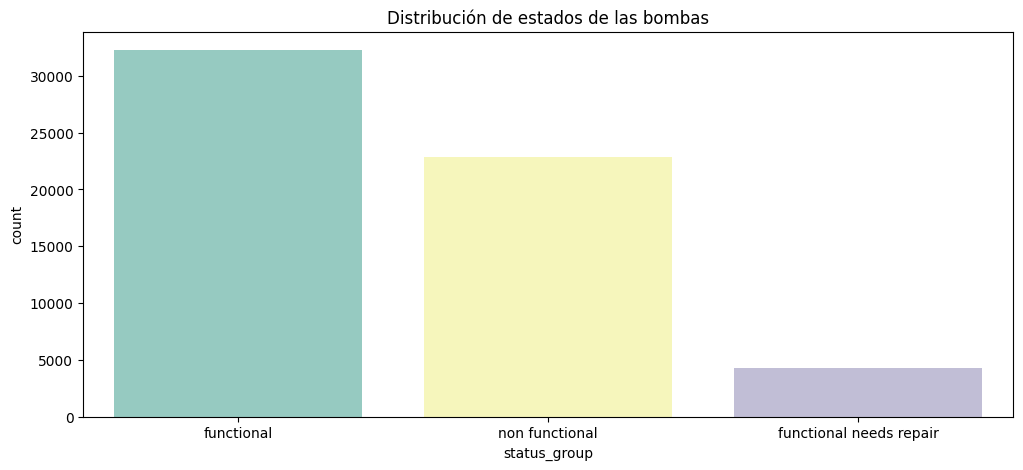

There were 22824 Shutdown (38.424%), 4317 Repair (7.268%) and 32259 Functional (54.308%).


In [ ]:
# 1. Gráfico de barras con conteo de las categorías en 'status_group'
plt.figure(figsize=(12,5))
sns.countplot(data=data_training, x="status_group", palette="Set3")
plt.title("Distribución de estados de las bombas")
plt.show()

# 2. Conteo de las categorías
counts = data_training["status_group"].value_counts()

# 3. Extraer cada categoría por nombre
Functional = counts['functional']
Repair = counts['functional needs repair']
Shutdown = counts['non functional']

# 4. Calcular porcentajes
total = Shutdown + Repair + Functional
perc_functional = (Functional / total) * 100
perc_repair = (Repair / total) * 100
perc_shutdown = (Shutdown / total) * 100

# 5. Imprimir resultados formateados
print(
    "There were {} Shutdown ({:.3f}%), {} Repair ({:.3f}%) and {} Functional ({:.3f}%)."
    .format(Shutdown, perc_shutdown, Repair, perc_repair, Functional, perc_functional)
)

clases muy desbalanceadas

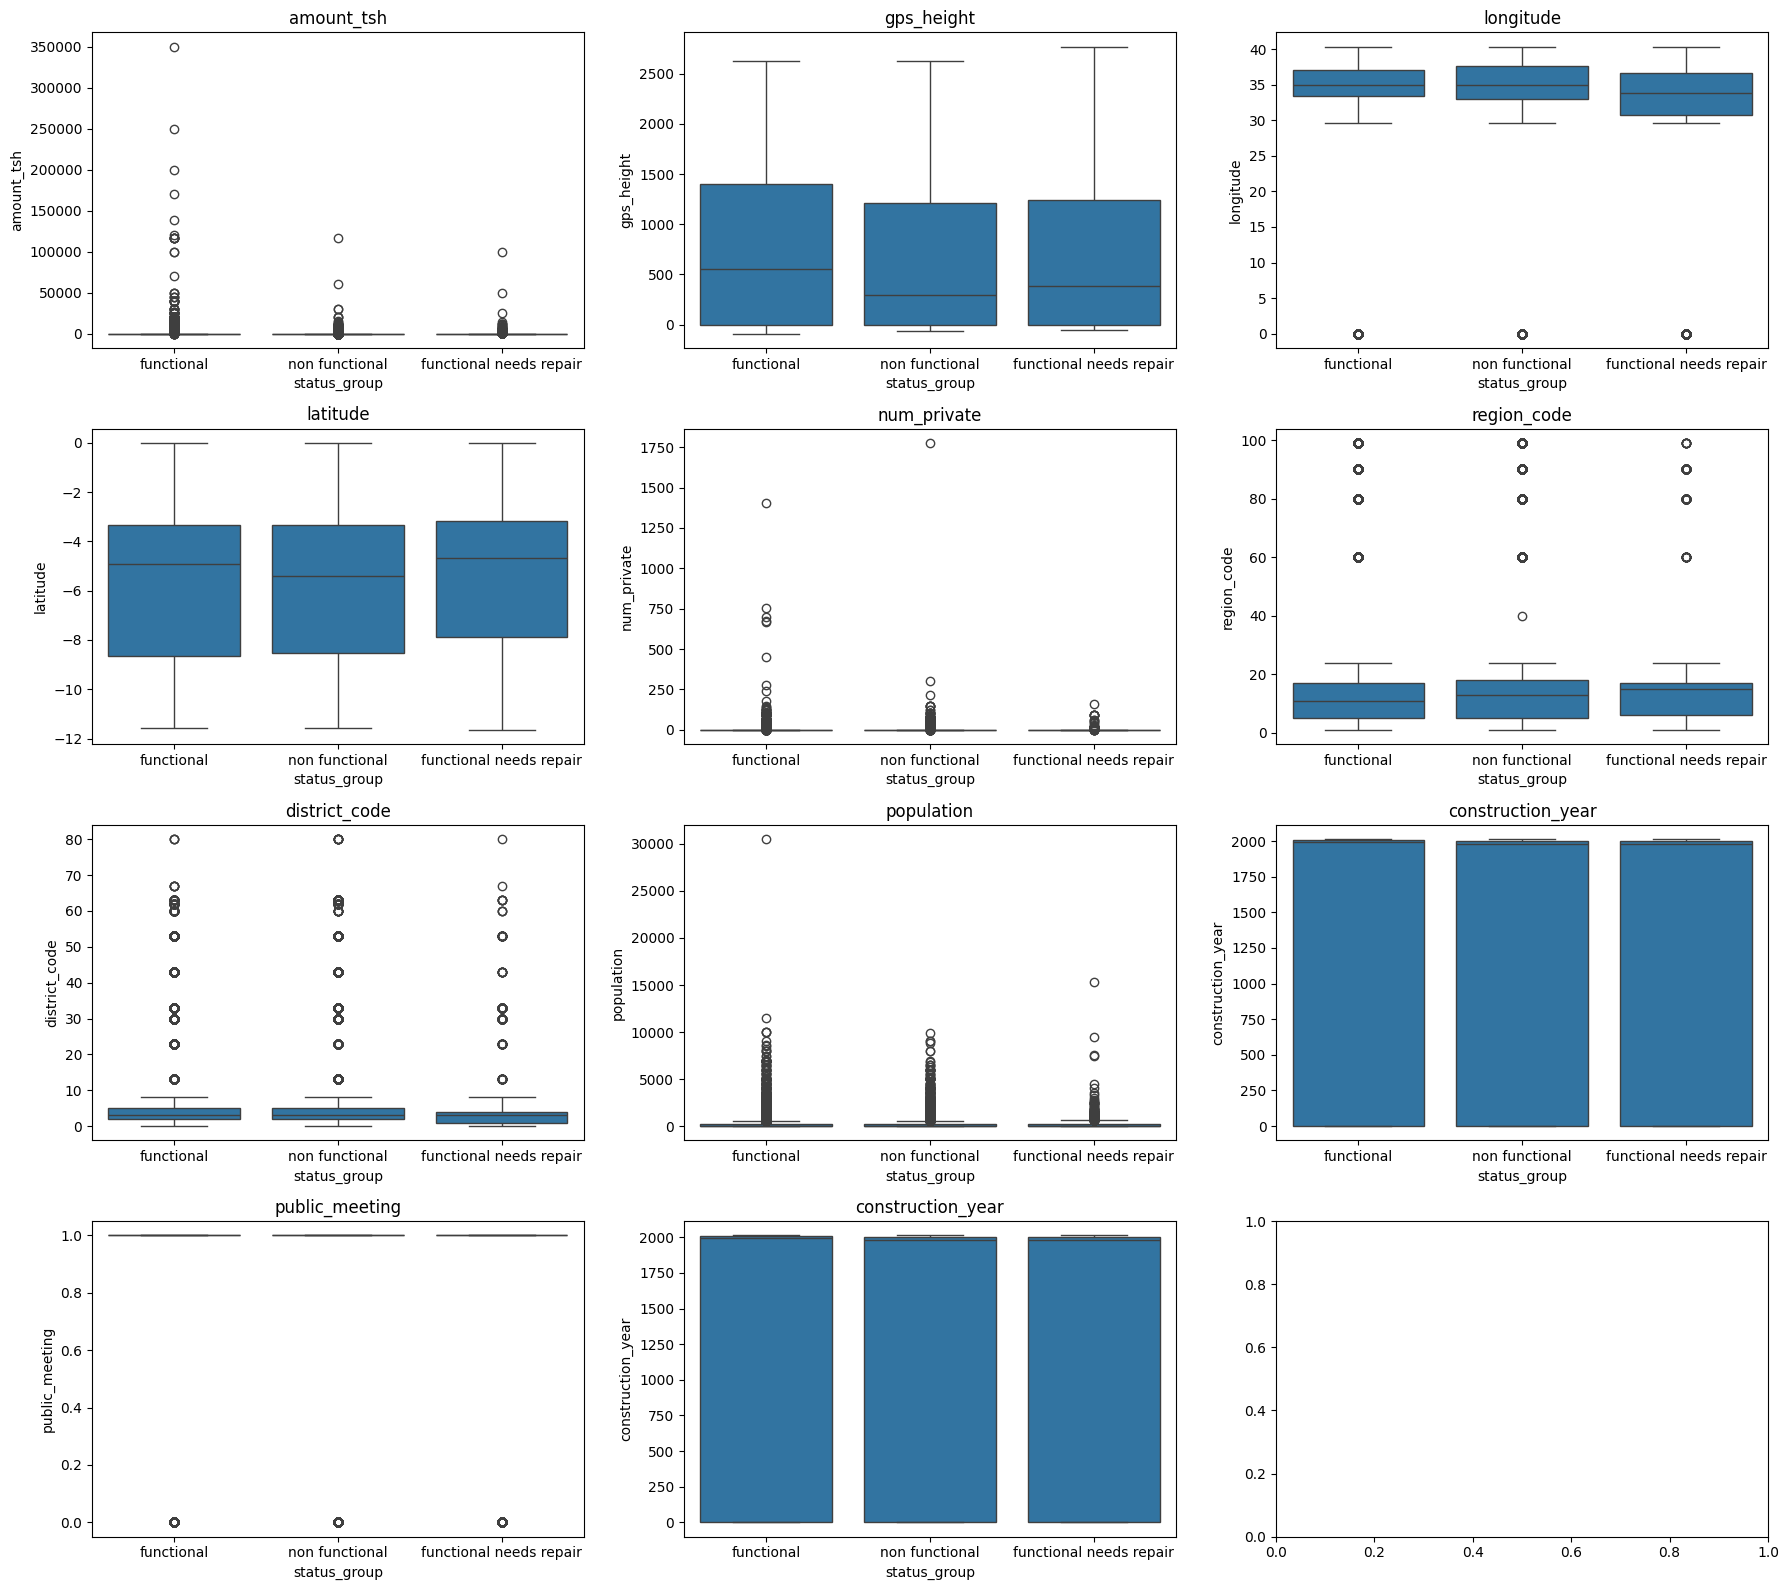

In [ ]:
numeric_cols = ["amount_tsh","gps_height","longitude","latitude","num_private","region_code","district_code",
                "population","construction_year","public_meeting","construction_year"]  # ajusta con tus numéricas reales

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18,16))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x="status_group", y=col, data=data_training, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

Estos boxplots ofrecen información valiosa, pero consideramos repetir el análisis aplicando una transformación logarítmica (log1p) a las variables numéricas con el fin de obtener mejores insights.

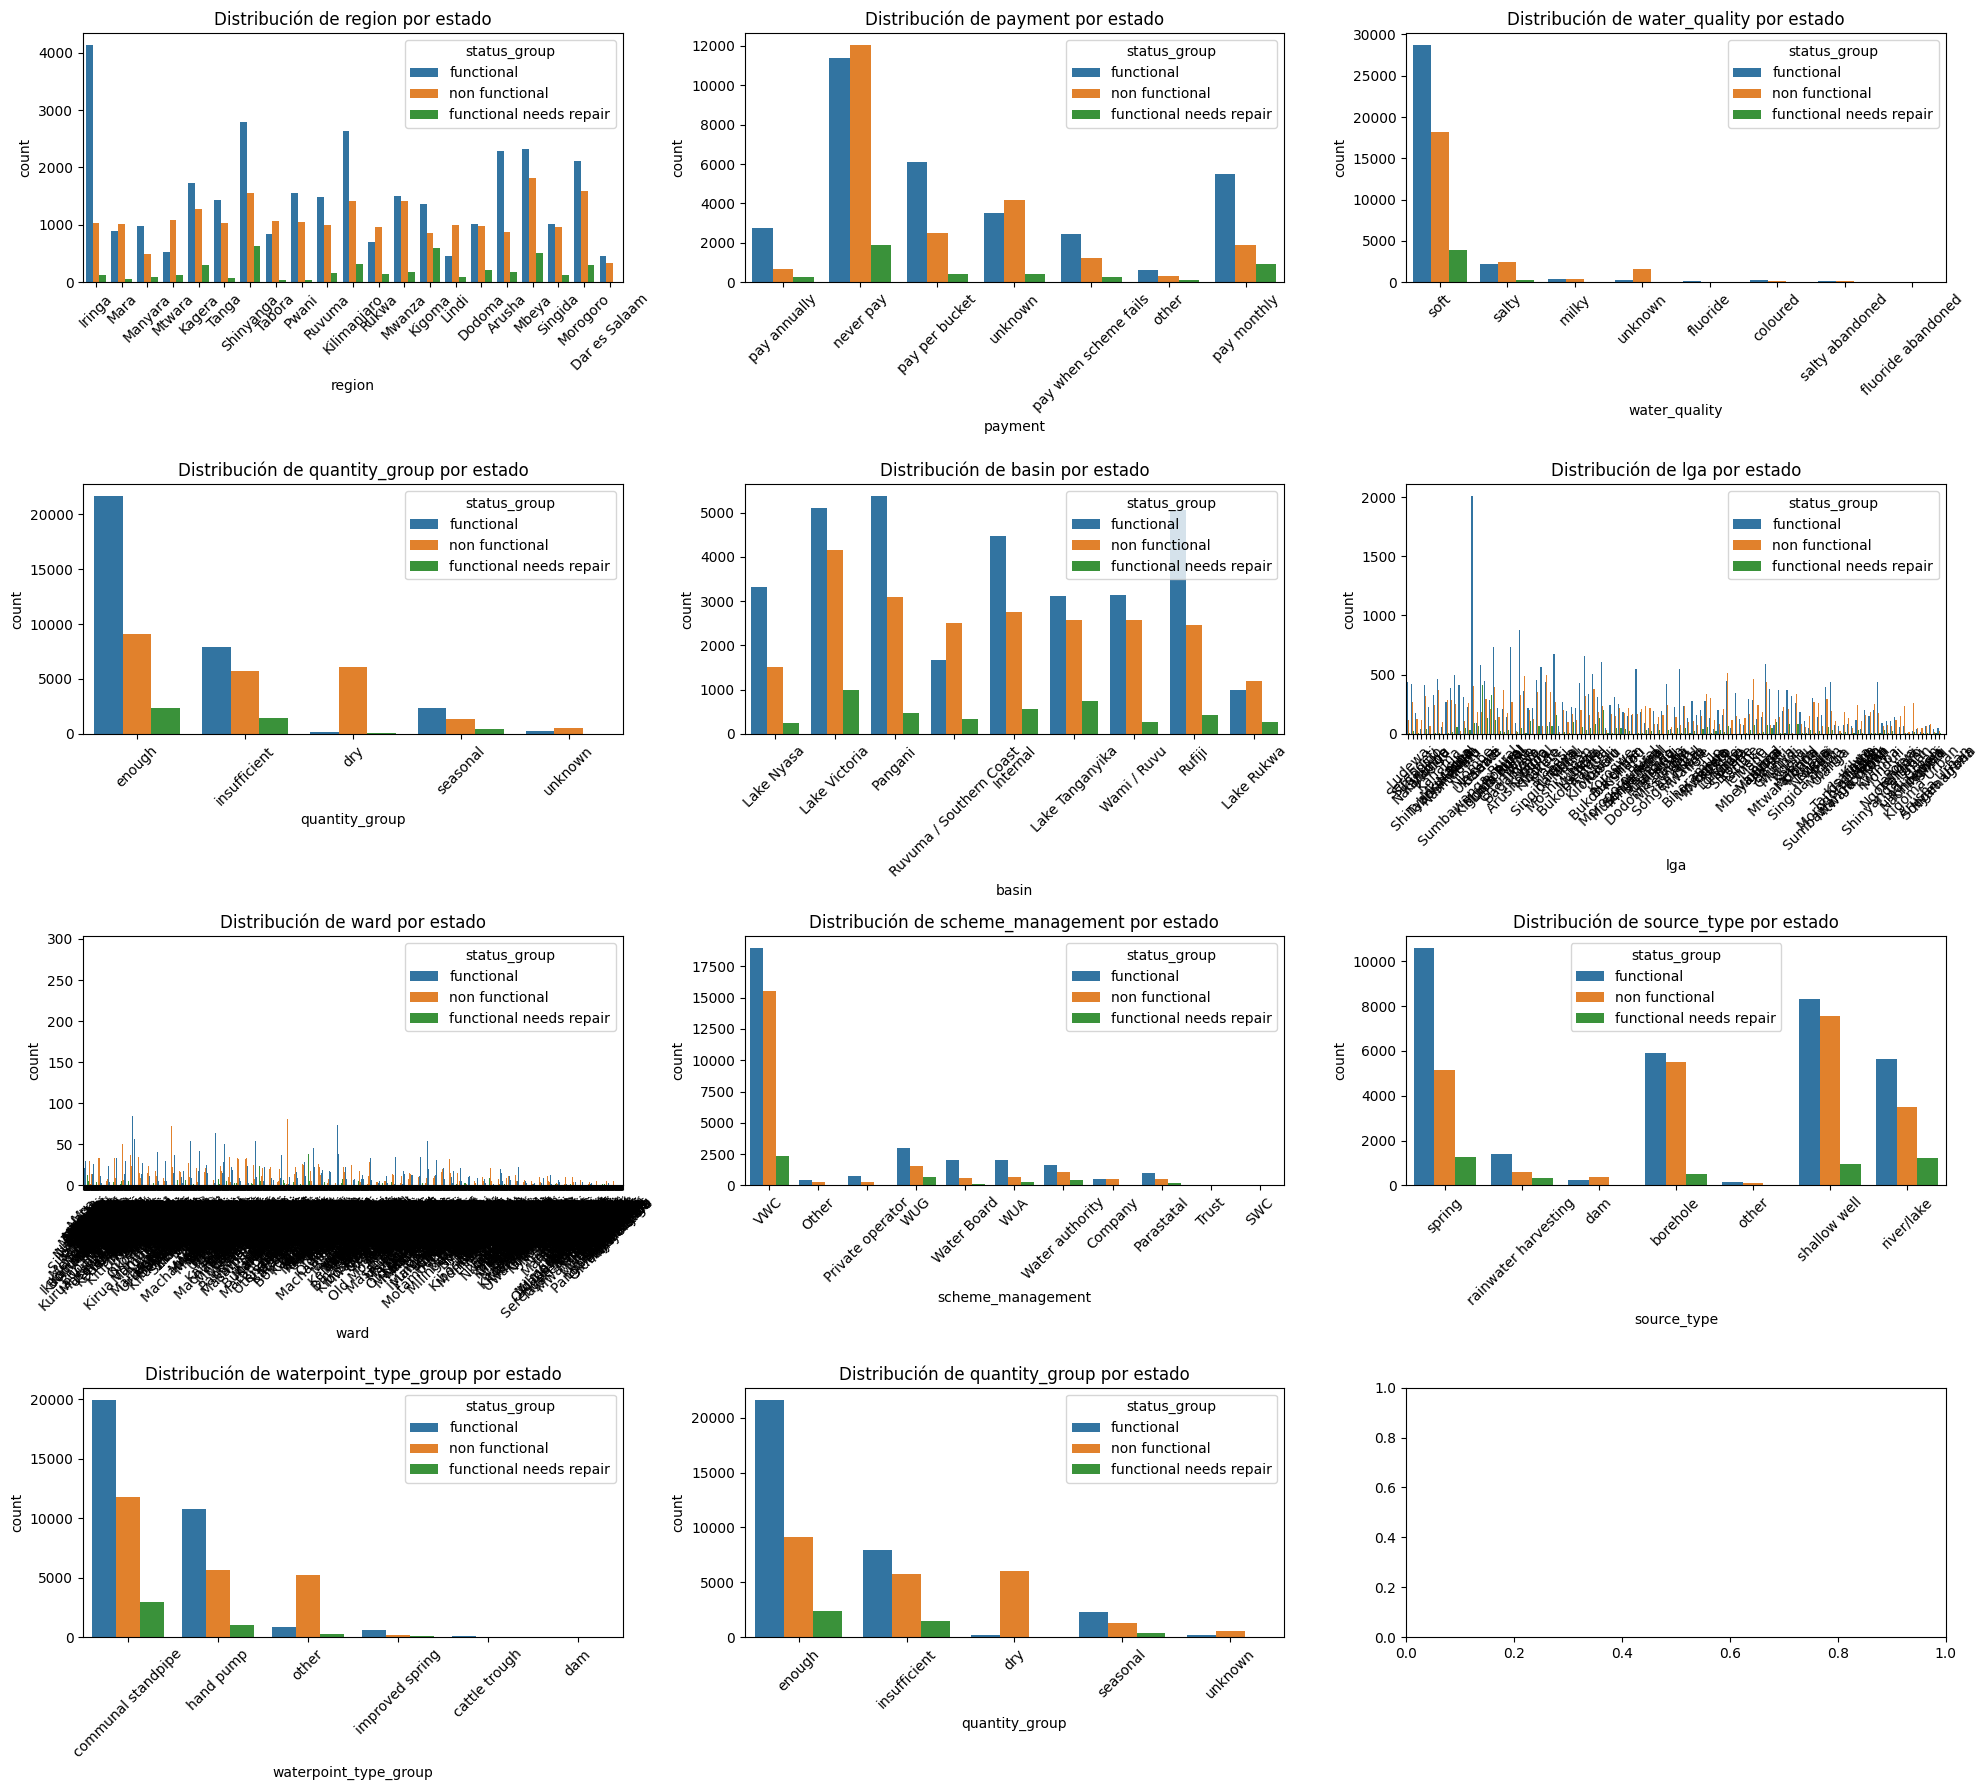

In [ ]:
# Variables categóricas de baja cardinalidad (para que no exploten las gráficas)
categorical_cols = ["region", "payment", "water_quality",
                    "quantity_group", "basin", "lga", "ward", "scheme_management",
                    "source_type", "waterpoint_type_group", "quantity_group"]

# Configuración del grid
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(20, 18))
axes = axes.flatten()

# Crear un countplot por variable
for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, hue="status_group", data=data_training, ax=axes[i])
    axes[i].set_title(f"Distribución de {col} por estado")
    axes[i].tick_params(axis='x', rotation=45)

# Ajustar diseño
plt.tight_layout()
plt.show()

Al igual que estas variables, hemos escogido solo las variables con menos cadenalidad para poder evaluar bien los graficos.

In [ ]:
# Seleccionar variables solo categoricas.
category_columns = data_training.select_dtypes(include=['object', 'category']).columns.tolist()

print("Variables categóricas:", category_columns)

# Calcular la cardinalidad (número de valores únicos) de cada columna categórica
cardinalities = data_training[category_columns].nunique()
print("\nCardinalidad por variable:\n", cardinalities.sort_values(ascending=False))

Variables categóricas: ['date_recorded', 'funder', 'installer', 'wpt_name', 'basin', 'subvillage', 'region', 'lga', 'ward', 'public_meeting', 'recorded_by', 'scheme_management', 'scheme_name', 'permit', 'extraction_type', 'extraction_type_group', 'extraction_type_class', 'management', 'management_group', 'payment', 'payment_type', 'water_quality', 'quality_group', 'quantity', 'quantity_group', 'source', 'source_type', 'source_class', 'waterpoint_type', 'waterpoint_type_group', 'status_group']

Cardinalidad por variable:
 wpt_name                 37399
subvillage               19287
scheme_name               2695
installer                 2145
ward                      2092
funder                    1896
date_recorded              356
lga                        125
region                      21
extraction_type             18
extraction_type_group       13
management                  12
scheme_management           11
source                      10
basin                        9
water_qu

In [ ]:
def normalize_text(x):
    if pd.isna(x):  # deja los NaN como están
        return x
    x = str(x).lower().strip()             # convierte a string, minúsculas, quita espacios extremos
    x = re.sub(r'\s+', "-", x)             # replace multiple spaces with a hyphen
    x = x.replace("/", "_")             # reemplaza múltiples espacios por 1
    x = x.replace(" ", "_")
    x = x.replace("-", "_")                # reemplaza espacios por _
    return x

# Seleccionar solo columnas de tipo "object" (texto), NO booleanos
text_cols = data_training.select_dtypes(include=["object"]).columns

# Aplicar la normalización solo a esas columnas
for col in text_cols:
    data_training[col] = data_training[col].apply(normalize_text)

print("Columnas normalizadas:", list(text_cols))

Columnas normalizadas: ['date_recorded', 'funder', 'installer', 'wpt_name', 'basin', 'subvillage', 'region', 'lga', 'ward', 'public_meeting', 'recorded_by', 'scheme_management', 'scheme_name', 'permit', 'extraction_type', 'extraction_type_group', 'extraction_type_class', 'management', 'management_group', 'payment', 'payment_type', 'water_quality', 'quality_group', 'quantity', 'quantity_group', 'source', 'source_type', 'source_class', 'waterpoint_type', 'waterpoint_type_group', 'status_group']


In [ ]:
# Normalizacion de columnas en el data set test_set
text_cols = test_set.select_dtypes(include=["object"]).columns

# Aplicar la normalización solo a esas columnas
for col in text_cols:
    test_set[col] = test_set[col].apply(normalize_text)

print("Columnas normalizadas:", list(text_cols))

Columnas normalizadas: ['date_recorded', 'funder', 'installer', 'wpt_name', 'basin', 'subvillage', 'region', 'lga', 'ward', 'public_meeting', 'recorded_by', 'scheme_management', 'scheme_name', 'permit', 'extraction_type', 'extraction_type_group', 'extraction_type_class', 'management', 'management_group', 'payment', 'payment_type', 'water_quality', 'quality_group', 'quantity', 'quantity_group', 'source', 'source_type', 'source_class', 'waterpoint_type', 'waterpoint_type_group']


Analizamos las variables con mayor cardenalidad

In [ ]:
data_training['funder'].nunique()

1891

In [ ]:
# Contar la frecuencia de funder: "Organización o persona que financió la construcción del pozo/punto de agua"
funders_freq = data_training['funder'].value_counts()

# Filtrar los que aparecen menos de 100 veces
rare_funders = funders_freq[funders_freq <3000]

print("Número de funder con <3000 registros:", rare_funders.shape[0])
print(rare_funders.head(20))  # mostrar solo 20 para no saturar

"Agrupar por organizacion, estado, religion"

Número de funder con <3000 registros: 1889
funder
hesawa                2202
rwssp                 1374
world_bank            1349
kkkt                  1287
world_vision          1246
unicef                1057
tasaf                  877
district_council       843
dhv                    829
private_individual     826
dwsp                   811
0                      777
norad                  765
germany_republi        610
tcrs                   602
ministry_of_water      590
water                  583
dwe                    484
netherlands            470
hifab                  450
Name: count, dtype: int64


'Agrupar por organizacion, estado, religion'

In [ ]:
data_training["ward"].nunique()

2092

In [ ]:
# Contar la frecuencia de "División administrativa menor dentro de un distrito (barrio/zona)"
ward_freq = data_training['ward'].value_counts()

# Filtrar los que aparecen menos de 3000 veces
rare_ward = ward_freq[ward_freq <3000]

print("Número de ward con <3000 registros:", rare_ward.shape[0])
print(rare_ward.head(20))  # mostrar solo 60 para no saturar

Número de ward con <3000 registros: 2092
ward
igosi            307
imalinyi         252
siha_kati        232
mdandu           231
nduruma          217
mishamo          203
kitunda          203
msindo           201
chalinze         196
maji_ya_chai     190
usuka            187
ngarenanyuki     172
chanika          171
vikindu          162
mtwango          153
matola           145
zinga_ikerege    141
maramba          139
wanging'ombe     139
itete            137
Name: count, dtype: int64


In [ ]:
data_training["installer"].nunique()

1906

In [ ]:
# Contar la frecuencia de installer: "Organización que instaló físicamente el pozo/punto de agua"
installer_freq = data_training['installer'].value_counts()

# Filtrar los que aparecen menos de 3000 veces
rare_installer = installer_freq[installer_freq <3000]

print("Número de installer con <3000 registros:", rare_installer.shape[0])
print(rare_installer.head(20))  # mostrar solo 60 para no saturar

Número de installer con <3000 registros: 1905
installer
government            1891
hesawa                1395
rwe                   1206
commu                 1065
danida                1050
district_council       965
kkkt                   910
0                      777
central_government     763
tcrs                   707
world_vision           699
danid                  624
ces                    610
community              555
gover                  511
amref                  443
lga                    413
tasaf                  411
wedeco                 398
fini_water             389
Name: count, dtype: int64


In [ ]:
data_training["subvillage"].nunique()

19286

In [ ]:
# Contar la frecuencia de sybvillage: "Sub-villa o aldea pequeña donde está localizado el pozo"
subvillage_freq = data_training['subvillage'].value_counts()

# Filtrar los que aparecen menos de 3000 veces
rare_subvillage = subvillage_freq[subvillage_freq <3000]

print("Número de subvillage con <3000 registros:", rare_subvillage.shape[0])
print(rare_subvillage.head(20))  # mostrar solo 60 para no saturar

#frequency encoding

Número de subvillage con <3000 registros: 19286
subvillage
madukani      508
shuleni       506
majengo       502
kati          373
mtakuja       262
sokoni        232
m             187
muungano      172
mbuyuni       164
mlimani       152
songambele    147
miembeni      134
msikitini     134
1             132
kibaoni       114
kanisani      111
i             109
mapinduzi     109
mjini         108
mjimwema      108
Name: count, dtype: int64


In [ ]:
data_training["wpt_name"].nunique()

37389

In [ ]:
# Contar la frecuencia de wpt_name: "Nombre del punto de agua (si tiene uno registrado)"
wpt_name_freq = data_training['wpt_name'].value_counts()

# Filtrar los que aparecen menos de 3000 veces
rare_wpt_name = wpt_name_freq[wpt_name_freq <3000]

print("Número de wpt_name con <3000 registros:", rare_wpt_name.shape[0])
print(rare_wpt_name.head(20))  # mostrar solo 60 para no saturar

#Eliminar variable

Número de wpt_name con <3000 registros: 37388
wpt_name
shuleni            1748
zahanati            830
msikitini           535
kanisani            323
bombani             271
sokoni              260
ofisini             254
school              208
shule_ya_msingi     199
shule               152
sekondari           146
muungano            133
mkombozi            111
madukani            104
hospital             94
mbugani              94
upendo               93
kituo_cha_afya       90
mkuyuni              88
umoja                84
Name: count, dtype: int64


In [ ]:
data_training["scheme_name"].nunique()

2504

In [ ]:
# Contar la frecuencia de scheme name "Nombre del sistema de agua bajo el que opera el pozo"
scheme_name_freq = data_training['scheme_name'].value_counts()

# Filtrar los que aparecen menos de 3000 veces
rare_scheme_name = scheme_name_freq[scheme_name_freq <3000]

print("Número de scheme_name con <3000 registros:", rare_scheme_name.shape[0])
print(rare_scheme_name.head(20))

Número de scheme_name con <3000 registros: 2504
scheme_name
k                                        685
borehole                                 546
chalinze_wate                            406
m                                        400
danida                                   379
government                               320
bagamoyo_wate                            296
ngana_water_supplied_scheme              270
wanging'ombe_water_supply_s              261
wanging'ombe_supply_scheme               236
i                                        229
uroki_bomang'ombe_water_sup              214
lyamungo_umbwe_water_supply              212
n                                        204
losaa_kia_water_supply                   204
kirua_kahe_gravity_water_supply_trust    193
machumba_estate_pipe_line                185
makwale_water_supplied_sche              166
kijiji                                   161
mkongoro_one                             157
Name: count, dtype: int64


#### Data Cleaning

In [ ]:
# Creamos las condiciones
conditions = [
    (data_training['status_group'] == "functional"),
    (data_training['status_group'] == "non_functional"),
    (data_training['status_group'] == "functional_needs_repair")
]

# Valores a asignar (respetando tu mapping)
values = [1, 0, 2]

# Sobrescribimos la columna 'status_group' con np.select
data_training['status_group'] = np.select(conditions, values)

In [ ]:
#Dividimos la data en Train y test para empezar las transformaciones

X = data_training.drop(columns=["status_group"])
y = data_training["status_group"]

# Dividir en train (80%) y test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# imputamos todos los NAN y los agrupamos en otra categoria llamada Other.
missed = ["scheme_management", "installer", "subvillage","public_meeting", "permit", "funder"]
for df in [X_train, X_test, X_comp]:
    for m in missed:
        df[m].fillna("other", inplace=True)

/tmp/ipython-input-548640336.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[m].fillna("other", inplace=True)


Imputacion de ceros

In [ ]:
# Calcular la mediana global de amount_tsh en X_train (ignorando ceros)
median_amount_tsh = X_train["amount_tsh"].replace(0, pd.NA).median()

# Reemplazar ceros en los 3 datasets
for df in [X_train, X_test, X_comp]:
    df["amount_tsh"] = df["amount_tsh"].replace(0, median_amount_tsh)

In [ ]:
# Calcular la mediana global de construction_year en X_train (ignorando ceros)
median_constr = X_train["construction_year"].replace(0, pd.NA).median()

# Reemplazar ceros en los 3 datasets
for df in [X_train, X_test, X_comp]:
    df["construction_year"] = df["construction_year"].replace(0, median_constr)

In [ ]:
# Calcular la moda en X_train (ignorando los 0)
moda_distr = X_train["district_code"].replace(0, pd.NA).mode()[0]

# Reemplazar ceros en los 3 datasets
for df in [X_train, X_test, X_comp]:
    df["district_code"] = df["district_code"].replace(0, moda_distr)

imputacion condicional

In [ ]:
def impute_conditional_median(train, test, comp, target_col, group_col):
    # Median values by group, usando solo X_train
    median_by_group = (train[train[target_col] != 0].groupby(group_col)[target_col].median())

    # Función auxiliar de imputación
    def impute(df):
        for group, median_value in median_by_group.items():
            mask = (df[target_col] == 0) & (df[group_col] == group)
            df.loc[mask, target_col] = median_value
        return df

    # Aplicar a los 3 conjuntos
    train, test, comp = impute(train), impute(test), impute(comp)
    return train, test, comp

In [ ]:
X_train, X_test, X_comp = impute_conditional_median(X_train, X_test, X_comp,
                                                    target_col="longitude",
                                                    group_col="region")

In [ ]:
print(X_train["date_recorded"].head(5))
print(X_train["date_recorded"].dtype)

16117    2013_02_10
39013    2013_02_07
42461    2012_12_24
23589    2011_07_12
41816    2011_03_01
Name: date_recorded, dtype: object
object


In [ ]:
#modificamos la variable
for df in [X_train, X_test, X_comp]:
    df["date_recorded"] = df["date_recorded"].str.replace("_", "-", regex=False)
    df["date_recorded"] = pd.to_datetime(df["date_recorded"], errors="coerce")
    df["year_recorded"] = df["date_recorded"].dt.year.astype("category")

In [ ]:
#Comprobamos que se realizo la modificacion de los datos
print(X_train[["date_recorded", "year_recorded"]].head())

      date_recorded year_recorded
16117    2013-02-10          2013
39013    2013-02-07          2013
42461    2012-12-24          2012
23589    2011-07-12          2011
41816    2011-03-01          2011


Creamos una variable llamada years_in_operation que proviene de year_recorded y construction_year

In [ ]:
#Creamos una variable mas para experimentar
for df in [X_train, X_test, X_comp]:
    df["years_in_operation"] = df["year_recorded"].astype(int) - df["construction_year"].astype(int)
    print(X_train[["construction_year", "year_recorded", "years_in_operation"]].head(5))

       construction_year year_recorded  years_in_operation
16117               2000          2013                  13
39013               2000          2013                  13
42461               2000          2012                  12
23589               2000          2011                  11
41816               1982          2011                  29
       construction_year year_recorded  years_in_operation
16117               2000          2013                  13
39013               2000          2013                  13
42461               2000          2012                  12
23589               2000          2011                  11
41816               1982          2011                  29
       construction_year year_recorded  years_in_operation
16117               2000          2013                  13
39013               2000          2013                  13
42461               2000          2012                  12
23589               2000          2011                  

Evaluamos la distribución (asimetría) de las variables numéricas. El objetivo es identificar qué variables están muy sesgadas y aplicarles una transformación logarítmica para estabilizar su varianza y mejorar la calidad del modelo.

In [ ]:
# skew por columna
def skew_series(s: pd.Series) -> float:
    return skew(pd.to_numeric(s, errors="coerce"), nan_policy="omit")

# columnas numéricas (excluye objetos y categóricas)
num_cols = X_train.select_dtypes(include=[np.number]).columns

skew_train = X_train[num_cols].apply(skew_series).sort_values(ascending=False)

high_skew_train = skew_train[skew_train.abs() > 0.5]

print("Skew en TRAIN (desc):")
print(skew_train)
print("Columnas con alto sesgo (|skew| > 0.5) en TRAIN:")
print(high_skew_train)

# (opcional) ver el skew de esas mismas columnas en TEST y COMP
cols_to_check = high_skew_train.index.tolist()

skew_test = X_test[cols_to_check].apply(skew_series).sort_values(ascending=False)
skew_comp = X_comp[cols_to_check].apply(skew_series).sort_values(ascending=False)

print("Skew de las mismas columnas en TEST:")
print(skew_test)
print("Skew de las mismas columnas en COMP:")
print(skew_comp)

Skew en TRAIN (desc):
num_private           85.926122
amount_tsh            48.516969
population            13.380972
district_code          3.969768
region_code            3.180191
years_in_operation     1.234424
gps_height             0.450868
id                    -0.001084
longitude             -0.079716
latitude              -0.155724
construction_year     -1.190240
dtype: float64
Columnas con alto sesgo (|skew| > 0.5) en TRAIN:
num_private           85.926122
amount_tsh            48.516969
population            13.380972
district_code          3.969768
region_code            3.180191
years_in_operation     1.234424
construction_year     -1.190240
dtype: float64
Skew de las mismas columnas en TEST:
amount_tsh            54.351875
num_private           18.246004
population             8.406033
district_code          3.931849
region_code            3.147911
years_in_operation     1.254165
construction_year     -1.208867
dtype: float64
Skew de las mismas columnas en COMP:
num_privat

Aplicamos log1

In [ ]:
for df in (X_train, X_test, X_comp):
    df[high_skew_train.index] = np.log1p(df[high_skew_train.index].abs())

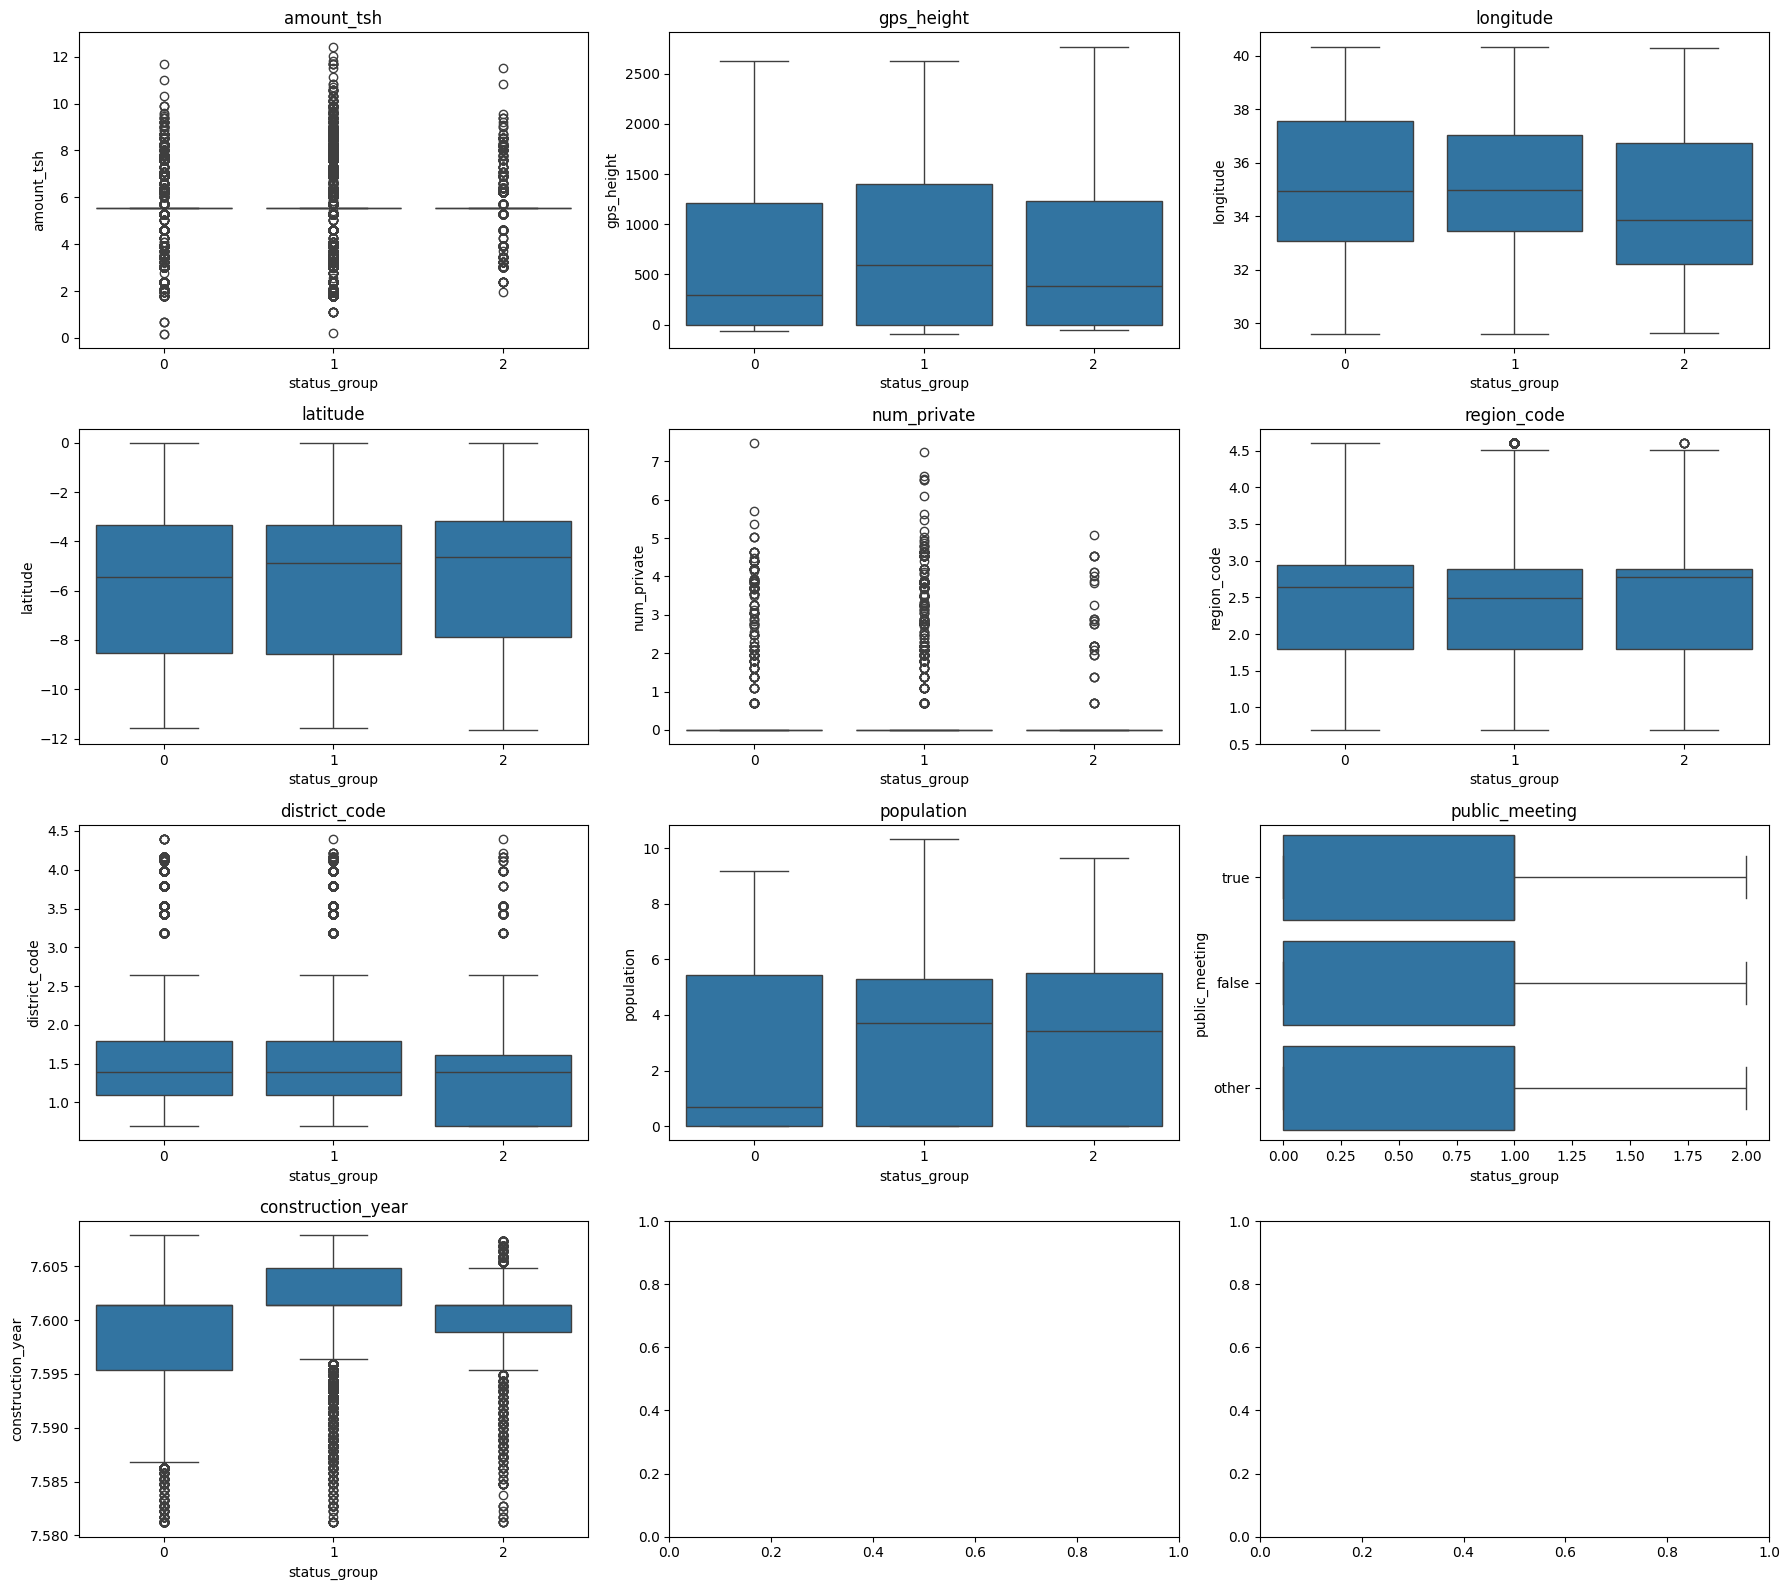

In [ ]:
# Variables numéricas en X_train despues del log1
numeric_cols = ["amount_tsh","gps_height","longitude","latitude","num_private","region_code","district_code",
                "population","public_meeting","construction_year"]

# Generar boxplots con las variables log-transformadas de X_train
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18,16))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=y_train, y=X_train[col],ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

**Boxplots después de la transformación log1p**

Luego de aplicar la transformación logarítmica (log1p) a las variables numéricas, repetí los boxplots para observar mejor la distribución de los datos y el comportamiento frente a la variable objetivo.

- *amount_tsh*: la mediana es similar en los tres grupos y, aunque el log redujo la dispersión, sigue habiendo muchos ceros. Aporta poca información al modelo.

- *gps_height*: las bombas funcionales tienden a estar a mayor altitud. Aunque hay solapamiento, puede ser una variable con cierta relevancia.

- *longitude / latitude*: no muestran diferencias claras por sí solas, pero en conjunto podrían ser útiles para capturar patrones geográficos.

- *num_private*: casi todos los valores son cero, con muy baja variabilidad. Poco informativa, candidata a eliminar o recodificar en binaria.

- *region_code / district_code*: distribuciones muy parecidas entre grupos, sin patrones claros. Probablemente redundantes con otras variables de localización.

- *population*: texto en cursiva las bombas que atienden a más personas suelen estar en funcionamiento. Variable potencialmente útil para el modelo.

- *construction_year:* muestra un patrón claro; las bombas más recientes tienden a ser funcionales, mientras que las antiguas aparecen más en los grupos de no funcionales o en reparación. Es una variable altamente informativa.

**Usamos el metodo haslinb para codificar las variables**

Para las variables wpt_name y subvillage, que presentan una cardinalidad muy alta (entre 20.000 y 30.000 categorías cada una), se aplicó el método de Feature Hashing. Esta técnica permite transformar categorías en un número fijo de variables mediante una función hash, reduciendo la dimensionalidad y evitando que el modelo se vea afectado por la gran dispersión de estas variables. Se definió un número fijo de features (512), lo cual permite representar estas variables de manera más compacta y eficiente para el entrenamiento del modelo.

In [ ]:
#hacer una transformacion de wpt_name
n_buckets = 512  # puedes ajustar según el tamaño

for df in [X_train, X_test, X_comp]:
    df["wpt_name_hashed"] = df["wpt_name"].astype(str).apply(
        lambda x: int(hashlib.md5(x.encode()).hexdigest(), 16) % n_buckets)

In [ ]:
#hacer una transformacion de subvillage
n_buckets = 512  # puedes ajustar según el tamaño

for df in [X_train, X_test, X_comp]:
    df["subvillage_hashed"] = df["subvillage"].astype(str).apply(
        lambda x: int(hashlib.md5(x.encode()).hexdigest(), 16) % n_buckets)

Para las variables funder e installer, que presentan una cardinalidad muy elevada, se seleccionaron las 100 categorías más frecuentes. Todas las demás categorías se agruparon bajo una sola etiqueta denominada “Other”, con el fin de reducir la dimensionalidad y evitar la dispersión de valores poco representativos en el modelo.

In [ ]:
# Concatenamos todos los datasets
data_all = pd.concat([X_train, X_test, X_comp])

# Top 100
top100_funder = data_all["funder"].value_counts().head(100).index.tolist()
top100_installer = data_all["installer"].value_counts().head(100).index.tolist()

print("Top 100 funder:", top100_funder[:10])      # solo muestra primeros 10
print("Top 100 installer:", top100_installer[:10])

Top 100 funder: ['government_of_tanzania', 'other', 'danida', 'Government Of Tanzania', 'hesawa', 'rwssp', 'world_bank', 'kkkt', 'world_vision', 'unicef']
Top 100 installer: ['dwe', 'other', 'DWE', 'government', 'hesawa', 'rwe', 'commu', 'danida', '0', 'district_council']


Frequency Encoding

Posteriormente, se aplicó Frequency Encoding a las variables ward, lga, funder e installer, ya que, tras la reducción de cardinalidad (agrupando categorías poco frecuentes en “Other”), estas variables podían ser representadas de manera más compacta a través de sus frecuencias relativas en el conjunto de datos

In [ ]:
# Variables a transformar con Frequency Encoding
freq_cols = ["ward", "lga", "funder", "installer"]

for col in freq_cols:
    # 1. Calcular frecuencias en X_train
    freq_map = X_train[col].value_counts().to_dict()

    # 2. Mapear a los 3 datasets
    for df in [X_train, X_test, X_comp]:
        df[col + "_freq"] = df[col].map(freq_map).fillna(0)

One-Hot Encoding (dummies)

Finalmente, se seleccionaron las variables con menor cardinalidad (menos de 23 categorías), sobre las cuales se aplicó One-Hot Encoding (dummies).

In [ ]:
# Variables a codificar con One-Hot Encoding
onehot_cols = [
    "basin", "region","scheme_management","extraction_type", "extraction_type_group",
    "extraction_type_class","management", "management_group", "payment", "water_quality",
    "quality_group", "quantity", "quantity_group","source","source_class", "waterpoint_type_group",
]

# --- 1) Aplicar One-Hot sobrescribiendo los originales ---
X_train = pd.get_dummies(X_train, columns=onehot_cols, drop_first=False)
X_test  = pd.get_dummies(X_test,  columns=onehot_cols, drop_first=False)
X_comp  = pd.get_dummies(X_comp,  columns=onehot_cols, drop_first=False)

# --- 2) Alinear columnas entre TRAIN, TEST y COMP ---
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)
X_train, X_comp = X_train.align(X_comp, join="left", axis=1, fill_value=0)

# --- 3) Verificar ---
print("Shape TRAIN:", X_train.shape)
print("Shape TEST:", X_test.shape)
print("Shape COMP:", X_comp.shape)

Shape TRAIN: (47520, 178)
Shape TEST: (11880, 178)
Shape COMP: (14850, 178)


In [ ]:
for df in (X_train, X_test, X_comp):
    df["public_meeting"] = df["public_meeting"].replace({"true":1,"false":0,"other":0, True:1, False:0}).astype(int)
    df["permit"] = df["permit"].replace({"true":1,"false":0,"other":0, True:1, False:0}).astype(int)

/tmp/ipython-input-1043022565.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["public_meeting"] = df["public_meeting"].replace({"true":1,"false":0,"other":0, True:1, False:0}).astype(int)
/tmp/ipython-input-1043022565.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["permit"] = df["permit"].replace({"true":1,"false":0,"other":0, True:1, False:0}).astype(int)
/tmp/ipython-input-1043022565.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old beha

La variable scheme_name presenta un 48% de valores faltantes. Debido a su alta proporción de missing, se transformó en una variable booleana, asignando 0 cuando no existe un nombre registrado y 1 cuando sí lo tiene

In [ ]:
# Crear variable booleana a partir de scheme_name
for df in [X_train, X_test, X_comp]:
    df["scheme_name_bool"] = df["scheme_name"].notna().astype(int)

# Verificación rápida
print(X_train["scheme_name_bool"].value_counts(normalize=True))

scheme_name_bool
1    0.514352
0    0.485648
Name: proportion, dtype: float64


In [ ]:
# Lista de nombres de las columnas en X_train
print(X_train.columns.tolist())

['id', 'amount_tsh', 'date_recorded', 'funder', 'gps_height', 'installer', 'longitude', 'latitude', 'wpt_name', 'num_private', 'subvillage', 'region_code', 'district_code', 'lga', 'ward', 'population', 'public_meeting', 'recorded_by', 'scheme_name', 'permit', 'construction_year', 'payment_type', 'source_type', 'waterpoint_type', 'year_recorded', 'years_in_operation', 'wpt_name_hashed', 'subvillage_hashed', 'ward_freq', 'lga_freq', 'funder_freq', 'installer_freq', 'basin_internal', 'basin_lake_nyasa', 'basin_lake_rukwa', 'basin_lake_tanganyika', 'basin_lake_victoria', 'basin_pangani', 'basin_rufiji', 'basin_ruvuma___southern_coast', 'basin_wami___ruvu', 'region_arusha', 'region_dar_es_salaam', 'region_dodoma', 'region_iringa', 'region_kagera', 'region_kigoma', 'region_kilimanjaro', 'region_lindi', 'region_manyara', 'region_mara', 'region_mbeya', 'region_morogoro', 'region_mtwara', 'region_mwanza', 'region_pwani', 'region_rukwa', 'region_ruvuma', 'region_shinyanga', 'region_singida', 're

In [ ]:
# Lista de columnas redundantes a eliminar
cols_to_drop = ["id", "amount_tsh", "funder", "installer", "scheme_name", "recorded_by", "ward", "lga", "num_private","date_recorded",
                "subvillage", "payment_type","source_type","waterpoint_type", "wpt_name",
                "basin", "region","scheme_management","extraction_type", "extraction_type_group",
               "extraction_type_class","management", "management_group", "payment", "water_quality",
               "quality_group", "quantity", "quantity_group","source","source_class", "waterpoint_type_group"]

# Eliminar en todos los datasets de una sola vez
for df_name, df in {"X_train": X_train, "X_test": X_test, "X_comp": X_comp}.items():
    df.drop(columns=cols_to_drop, errors="ignore", inplace=True)
    print(f"Dimensiones de {df_name} después:", df.shape)

Dimensiones de X_train después: (47520, 164)
Dimensiones de X_test después: (11880, 164)
Dimensiones de X_comp después: (14850, 164)


In [ ]:
X_train.head()

,gps_height,longitude,latitude,region_code,district_code,population,public_meeting,permit,construction_year,year_recorded,...,source_class_groundwater,source_class_surface,source_class_unknown,waterpoint_type_group_cattle_trough,waterpoint_type_group_communal_standpipe,waterpoint_type_group_dam,waterpoint_type_group_hand_pump,waterpoint_type_group_improved_spring,waterpoint_type_group_other,scheme_name_bool
16117,0,32.596930,-3.790983e+00,2.890372,1.386294,0.000000,1,1,7.601402,2013,...,True,False,False,False,False,False,False,False,True,0
39013,268,39.225084,-1.101662e+01,4.510860,3.526361,0.693147,1,1,7.601402,2013,...,True,False,False,False,True,False,False,False,False,0
42461,0,33.083727,-2.000000e-08,2.995732,1.098612,0.000000,1,1,7.601402,2012,...,False,True,False,False,True,False,False,False,False,1
23589,0,31.532592,-1.560903e+00,2.944439,1.098612,0.000000,1,1,7.601402,2011,...,False,True,False,False,True,False,False,False,False,1
41816,1642,35.557895,-7.947067e+00,2.484907,0.693147,0.693147,1,1,7.592366,2011,...,True,False,False,False,True,False,False,False,False,1


SMOTE

La variable objetivo *status_group* presentaba un desbalance significativo en las clases. Para mitigar este problema, se aplicó la técnica **SMOTE (Synthetic Minority Over-sampling Technique)**, ajustando la proporción de las clases minoritarias respecto a la mayoritaria *class 1 = functional*

In [ ]:
print("Distribución original:", Counter(y_train))

target_counts = {
    0: int(0.9 * 25807),   # 23,226
    2: int(0.8 * 25807)}    # 20,645

sm = SMOTE(sampling_strategy=target_counts, k_neighbors=5, random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Distribución después:", Counter(y_train_res))

Distribución original: Counter({1: 25807, 0: 18259, 2: 3454})
Distribución después: Counter({1: 25807, 0: 23226, 2: 20645})


MODELO RANDOM FOREST

In [ ]:
# Identificar columnas categóricas
categorical_cols = X_train_res.select_dtypes(include=["object", "category"]).columns.tolist()

# Preprocesamiento: One-Hot para categóricas, dejar numéricas igual
preprocessor = ColumnTransformer(transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],remainder="passthrough")

# Pipeline: preprocesamiento + modelo
rf_pipeline = Pipeline(steps=[("preprocessor", preprocessor),("model", RandomForestClassifier(
        n_estimators=200, random_state=42, n_jobs=-1))])

# Entrenamiento
rf_pipeline.fit(X_train_res, y_train_res)

# Predicciones
y_pred_rf = rf_pipeline.predict(X_test)

# Evaluación
print("Accuracy (Random Forest):", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Accuracy (Random Forest): 0.8048821548821549

Confusion Matrix:
 [[3615  853   97]
 [ 557 5607  288]
 [ 132  391  340]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.79      0.82      4565
           1       0.82      0.87      0.84      6452
           2       0.47      0.39      0.43       863

    accuracy                           0.80     11880
   macro avg       0.71      0.68      0.70     11880
weighted avg       0.80      0.80      0.80     11880



El modelo *Random Forest* logra un desempeño sólido para las clases mayoritarias (functional y non functional), pero aún no consigue distinguir bien las bombas que requieren reparación. Esto indica que, aunque el modelo es útil para clasificar correctamente la mayoría de los casos, se necesitaría un tratamiento adicional (balanceo de clases, nuevas variables, o modelos más especializados) para mejorar la detección de la clase minoritaria (needs repair).

In [ ]:
# --- 1) Predicciones sobre X_comp ---
y_comp_rf = rf_pipeline.predict(X_comp)   # predicciones como 0/1/2

# --- 2) Diccionario inverso para devolver a texto ---
inv_map = {
    1: "functional",
    0: "non functional",
    2: "functional needs repair"
}

# Convertir a etiquetas de texto
y_comp_labels = pd.Series(y_comp_rf).map(inv_map)

# --- 3) Cargar el SubmissionFormat oficial ---
submission = pd.read_csv("/content/drive/MyDrive/COMPLUTENSE_MASTER/11_machine_learning3/modelo_driven_data/submissionformat.csv")

# --- 4) Reemplazar la columna status_group con tus predicciones en texto ---
submission["status_group"] = y_comp_labels

# --- 5) Guardar a CSV ---
submission.to_csv("submission_rf.csv", index=False)
print("Archivo 'submission_rf.csv' generado correctamente 🎉")

# --- 6) (Opcional) Descargar a tu ordenador ---
from google.colab import files
files.download("submission_rf.csv")

# Vista previa
print(submission.head())

Archivo 'submission_rf.csv' generado correctamente 🎉


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

      id    status_group
0  50785  non functional
1  51630      functional
2  17168      functional
3  45559  non functional
4  49871      functional


MODELO LGBMCClassifier

In [ ]:
# --- 1) Preparar datos (tipos eficientes) ---
Xtr   = X_train_res.astype("float32")
ytr   = y_train_res.astype(int)
Xval  = X_test.astype("float32")
yval  = y_test.astype(int)

# Conjunto de clases (robusto aunque falte alguna en yval)
ALL_LABELS = sorted(np.unique(ytr))  # debería ser [0,1,2]

# --- 2) Definir modelo ---
clf = LGBMClassifier(
    objective="multiclass",
    num_class=len(ALL_LABELS),
    n_estimators=5000,          # grande + early stopping
    learning_rate=0.03, #estaba en 0.05 y lo baje a 0.03
    num_leaves=93, #estaba en 63 y lo subi a 93
    min_data_in_leaf=70, #estaba en 40 y lo subi a 70
    subsample=0.8,              # bagging_fraction estaba en 0,9 lo baje a 0,8
    subsample_freq=1,           # bagging_freq
    colsample_bytree=0.8,       # feature_fraction estaba en 0,9 lo baje a 0,8
    reg_lambda=1.0,             # L2
    random_state=42,
    n_jobs=-1,
    # Si quieres empujar recall de la clase 2, prueba:
    class_weight={0:1, 1:1, 2:2}
)

# --- 3) Entrenamiento con early stopping ---
clf.fit(
    Xtr, ytr,
    eval_set=[(Xtr, ytr), (Xval, yval)],
    eval_metric="multi_logloss",
    callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=True)] # Use lgb.early_stopping callback
)


print("Best iteration:", clf.best_iteration_)

# --- 4) Predicciones y métricas ---
proba  = clf.predict_proba(Xval)              # shape (n_samples, 3)
ypred  = np.argmax(proba, axis=1)

print("\nMulti LogLoss:", log_loss(yval, proba, labels=ALL_LABELS))

try:
    auc = roc_auc_score(yval, proba, multi_class="ovr")
    print("ROC AUC (OVR):", auc)
except Exception as e:
    print("ROC AUC no calculable:", e)

print("\nClassification report (macro):")
print(classification_report(yval, ypred, labels=ALL_LABELS, digits=4, zero_division=0))

print("\nMatriz de confusión (labels en orden):", ALL_LABELS)
print(confusion_matrix(yval, ypred, labels=ALL_LABELS))

# --- 5) Importancias de variables (ganancia) ---
# En el wrapper, feature_importances_ es por "split"; para "gain" usamos el booster:
booster = clf.booster_
gain_importance = pd.Series(
    booster.feature_importance(importance_type="gain"),
    index=Xtr.columns,
    name="gain"
).sort_values(ascending=False)
print("\nTop 20 features (gain):")
print(gain_importance.head(20))

[LightGBM] [Warning] min_data_in_leaf is set=70, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=70
[LightGBM] [Warning] min_data_in_leaf is set=70, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=70
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.599334 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3754
[LightGBM] [Info] Number of data points in the train set: 69678, number of used features: 160
[LightGBM] [Warning] min_data_in_leaf is set=70, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=70
[LightGBM] [Info] Start training from score -1.358120
[LightGBM] [Info] Start training from score -1.252746
[LightGBM] [Info] Start training from score -0.782772
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1049]	training's mul

El modelo LightGBM muestra un desempeño general muy sólido, comparable al Random Forest, con un ROC AUC superior (0.89) que indica mejor separación entre clases. Sin embargo, al igual que en Random Forest, la clase minoritaria (needs repair) sigue siendo difícil de predecir con precisión y recall aceptables.

Esto sugiere que, aunque LightGBM mejora ligeramente la detección de esta clase

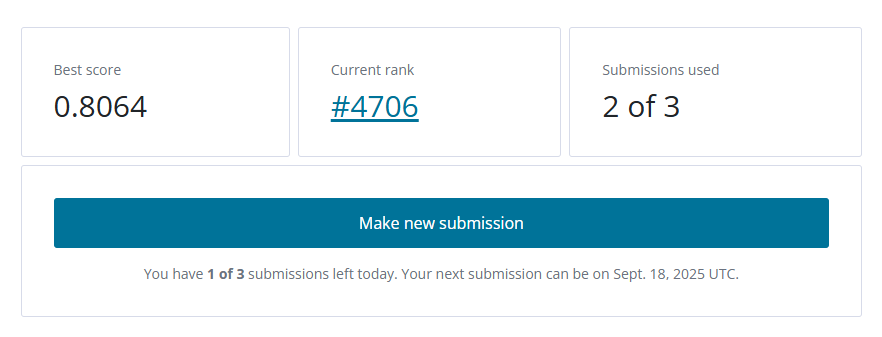

Al finalizar el entrenamiento, observé que el modelo no logra predecir adecuadamente las bombas que requieren reparación. A pesar de realizar varios intentos de codificación sobre las variables con mayor cardinalidad, el desempeño del modelo no superó un 80,60% de precisión